# Models Demo

This demo shows how the models considered for the project architecture act on the raw dataset.

In [1]:
import os
import torch
from PIL import Image
import torchvision.transforms as T
import cv2
import numpy as np
from models import utils_hpe
import sys
from sixdrepnet import SixDRepNet

img_path = "dataset/test/raw/p11_image_47.png"   

In [2]:
if torch.cuda.is_available():
    device_name = "cuda"
elif torch.backends.mps.is_available():
    device_name = "mps"
else:
    device_name = "cpu"
    
device = torch.device(device_name)
print(f"Code runs in {device}")

Code runs in cuda


## Model1 (TokenHPE)

Cloned from: https://github.com/zc2023/TokenHPE/tree/main

In [3]:
sys.path.append("./models")

from token_hpe import TokenHPE

model_hpe = TokenHPE(depth=3)
checkpoint = torch.load("./weights/TokenHPEv1-ViTB-224_224-lyr3.tar", map_location="cpu")

state_dict = checkpoint["model_state_dict"]

model_hpe.load_state_dict(state_dict, strict=True)
model_hpe.eval()

==> Add Sine PositionEmbedding~


C:\Users\enric\AppData\Local\Temp\ipykernel_8584\2143934912.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("./weights/TokenHPEv1-ViTB-224_224-ly

TokenHPE(
  (feature_extractor): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (drop_path): Identity()
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (act): GELU(approximate='none')
          (fc2): Linear(in_features=3072, out_features=768, bias=True)
          (drop): Dropout(p=0.0, inplace=False)
        )
      )

In [5]:
transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor()
    # T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])


img = Image.open(img_path).convert("RGB")
x = transform(img).unsqueeze(0)

with torch.no_grad():
    pred_rotation_matrix, ori_9_d = model_hpe(x)

print("Predicted Rotation Matrix Shape:", pred_rotation_matrix.shape)
print("Predicted Rotation Matrix:\n", pred_rotation_matrix[0])

euler = utils_hpe.compute_euler_angles_from_rotation_matrices(pred_rotation_matrix) * 180 / np.pi
pitch = float(euler[0, 0])
yaw   = float(euler[0, 1])
roll  = float(euler[0, 2])

print("Pitch:", pitch, "Yaw:", yaw, "Roll:", roll)

cv_img = cv2.imread(img_path)

utils_hpe.draw_axis(cv_img, yaw, pitch, roll, size=100)

cv2.imshow("Pose", cv_img)
cv2.waitKey(0)
cv2.destroyAllWindows()


Predicted Rotation Matrix Shape: torch.Size([1, 3, 3])
Predicted Rotation Matrix:
 tensor([[ 0.9722, -0.1918,  0.1344],
        [ 0.2054,  0.9740, -0.0958],
        [-0.1126,  0.1207,  0.9863]])
Pitch: 6.976690769195557 Yaw: 6.463435649871826 Roll: 11.927332878112793


# Model2 (SixDRepNet)

Cloned from: https://github.com/thohemp/6DRepNet

In [ ]:
model_sixD = SixDRepNet()

img = cv2.imread(img_path)

pitch, yaw, roll = model_sixD.predict(img)

model_sixD.draw_axis(img, yaw, pitch, roll)

cv2.imshow("test_window", img)
cv2.waitKey(0)

-1

# Model3 (WHENet)

Cloned from: https://github.com/Ascend-Research/HeadPoseEstimation-WHENet

In [7]:
import cv2
import numpy as np
import sys, os
sys.path.insert(0, os.path.abspath('./models'))
from whenet import WHENet

model_whenet = WHENet(snapshot='weights/WHENet.h5')

img = cv2.imread(img_path)

yaw, pitch, roll = model_whenet.predict(img)

print("Yaw:", yaw, "Pitch:", pitch, "Roll:", roll)

model_whenet.draw_axis(img, yaw, pitch, roll)

cv2.imshow("WHENet Prediction", img)
cv2.waitKey(0)
cv2.destroyAllWindows()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Yaw: -1.42828369140625 Pitch: -16.066162109375 Roll: -5.47381591796875


# Final Comparison

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step

Ground Truth | Pitch:  +2.75° | Yaw:  -1.98° | Roll: +17.35°
Model Identifier | Pitch (Error)   | Yaw (Error)     | Roll (Error)    | MAE    
TokenHPE         |  +6.98 ( 4.23°) |  +6.46 ( 8.45°) | +11.93 ( 5.42°) |  6.03°
SixDRepNet       |  -9.16 (11.91°) |  +3.85 ( 5.84°) |  +2.13 (15.22°) | 10.99°
WHENet           | -16.07 (18.82°) |  -1.43 ( 0.55°) |  -5.47 (22.82°) | 14.06°



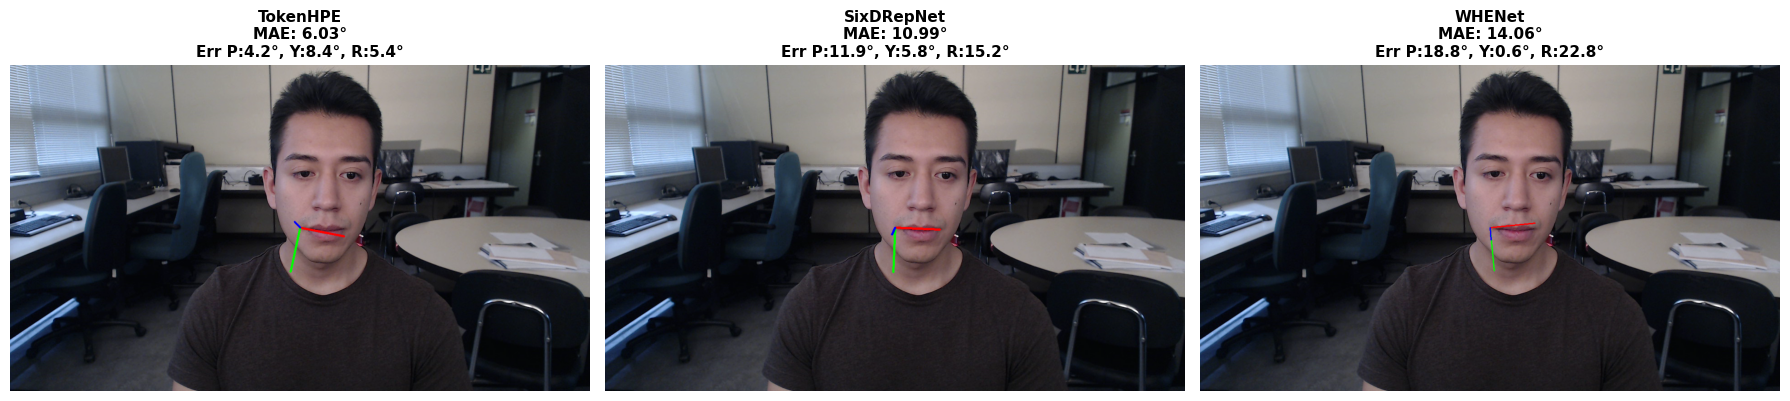

In [8]:
from utils import compare_head_pose_models_with_error

m_thpe, m_sixD, m_whenet = model_hpe, model_sixD, model_whenet

compare_head_pose_models_with_error(img_path, m_thpe, m_sixD, m_whenet)

We can appreciate how the best model was clearly TokenHPE, followed by SixDRepNet and finally WHENet.